# NFL Combine Exploratory Data Analysis

## Questions to explore
* How do combine performance metrics differ by position?
* Which combine metrics are most associated with being drafted?
* How have combine athletes changed over time?
* What physical traits do early round draft picks share?

# Load Data and Libraries

In [1]:
install.packages(c("tidyverse", "janitor", "corrplot"))
library(tidyverse)
library(janitor)
library(corrplot)

Installing packages into ‘C:/Users/Defte/AppData/Local/R/win-library/4.5’
(as ‘lib’ is unspecified)


trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/tidyverse_2.0.0.zip'
trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/janitor_2.2.1.zip'
trying URL 'https://cran.rstudio.com/bin/windows/contrib/4.5/corrplot_0.95.zip'


package ‘tidyverse’ successfully unpacked and MD5 sums checked
package ‘janitor’ successfully unpacked and MD5 sums checked
package ‘corrplot’ successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Defte\AppData\Local\Temp\RtmpaeC6cH\downloaded_packages
── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors

Attaching package: ‘janitor’

The following objects are maske

In [2]:
df <- read.csv("C:/Users/Defte/Downloads/combine.csv") |> 
  clean_names()


# NFL Combine Dataset – Data Dictionary

Player Information
| Column        | Type        | Description                                          |
| ------------- | ----------- | ---------------------------------------------------- |
| **year**      | Numeric     | Year the player participated in the NFL Combine.     |
| **name**      | Character   | Player’s full name.                                  |
| **firstname** | Character   | Player’s first name.                                 |
| **lastname**  | Character   | Player’s last name.                                  |
| **position**  | Categorical | Primary playing position (WR, RB, QB, CB, LB, etc.). |

Physical Measurements
| Column                | Type    | Description                         |
| --------------------- | ------- | ----------------------------------- |
| **heightfeet**        | Numeric | Height in feet portion.             |
| **heightinches**      | Numeric | Remaining inches portion of height. |
| **heightinchestotal** | Numeric | Total height in inches.             |
| **weight**            | Numeric | Player weight in pounds.            |
| **arms**              | Numeric | Arm length in inches.               |
| **hands**             | Numeric | Hand size in inches.                |

Speed & Agility Drills
| Column        | Type    | Description                                      |
| ------------- | ------- | ------------------------------------------------ |
| **fortyyd**   | Numeric | 40-yard dash time in seconds.                    |
| **twentyyd**  | Numeric | 20-yard dash split time in seconds.              |
| **tenyd**     | Numeric | 10-yard dash split time in seconds.              |
| **twentyss**  | Numeric | 20-yard shuttle time in seconds (short shuttle). |
| **threecone** | Numeric | 3-cone drill time in seconds.                    |

Explosion / Power Metrics
| Column       | Type    | Description                         |
| ------------ | ------- | ----------------------------------- |
| **vertical** | Numeric | Vertical jump height in inches.     |
| **broad**    | Numeric | Broad jump distance in inches.      |
| **bench**    | Numeric | Bench press repetitions at 225 lbs. |

Draft Outcomes
| Column        | Type    | Description                                 |
| ------------- | ------- | ------------------------------------------- |
| **round**     | Numeric | NFL draft round selected (NA if undrafted). |
| **pick**      | Numeric | Pick number within draft round.             |
| **pickround** | Numeric | Overall pick number within the round.       |
| **picktotal** | Numeric | Overall draft pick number.                  |
| **nflgrade**  | Numeric | Prospect grade assigned before draft.       |

Background Information
| Column        | Type      | Description                     |
| ------------- | --------- | ------------------------------- |
| **college**   | Character | College the player attended.    |
| **wonderlic** | Numeric   | Wonderlic cognitive test score. |





## Replace 0 values with NULL to indicate non-participation or opt-out

In [3]:
df <- df |>
  mutate(across(where(is.numeric), ~na_if(., 0))) # look across row replace numeric 0 with NA

# Summary Stats

In [4]:
summary(df) # calculates mean, meadian, and NA's for all columns

      year          name            firstname           lastname           position           heightfeet     heightinches   
 Min.   :1999   Length:4947        Length:4947        Length:4947        Length:4947        Min.   :5.000   Min.   : 1.000  
 1st Qu.:2003   Class :character   Class :character   Class :character   Class :character   1st Qu.:6.000   1st Qu.: 2.000  
 Median :2007   Mode  :character   Mode  :character   Mode  :character   Mode  :character   Median :6.000   Median : 4.000  
 Mean   :2007                                                                               Mean   :5.805   Mean   : 4.507  
 3rd Qu.:2012                                                                               3rd Qu.:6.000   3rd Qu.: 6.000  
 Max.   :2015                                                                               Max.   :6.000   Max.   :11.875  
                                                                                                            NA's   :149     


#  Summary Visuals

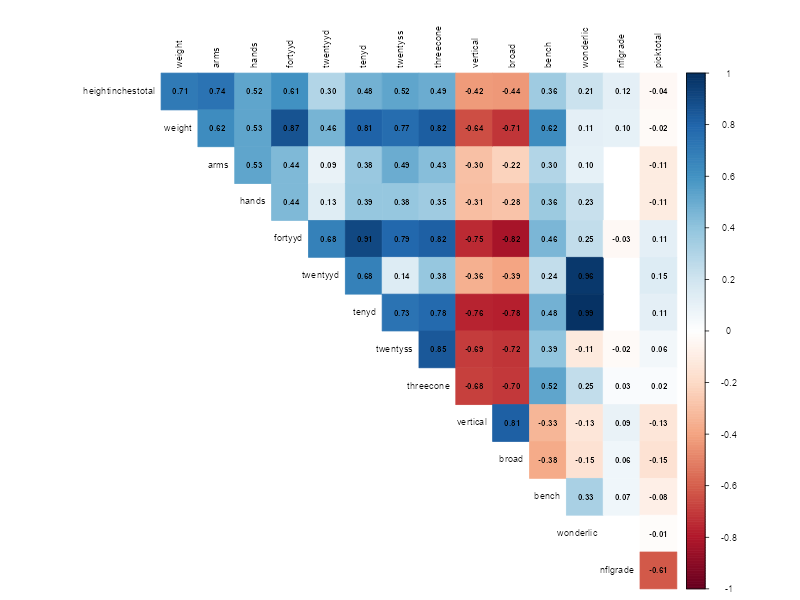

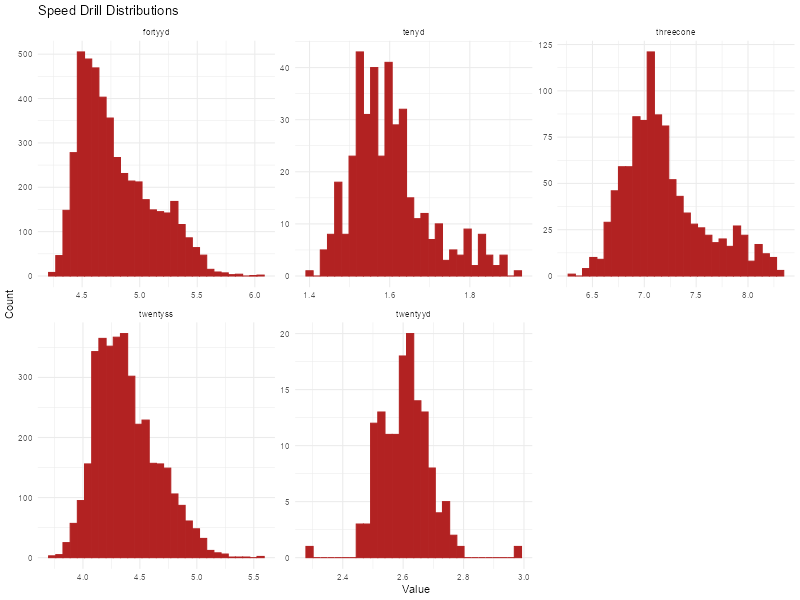

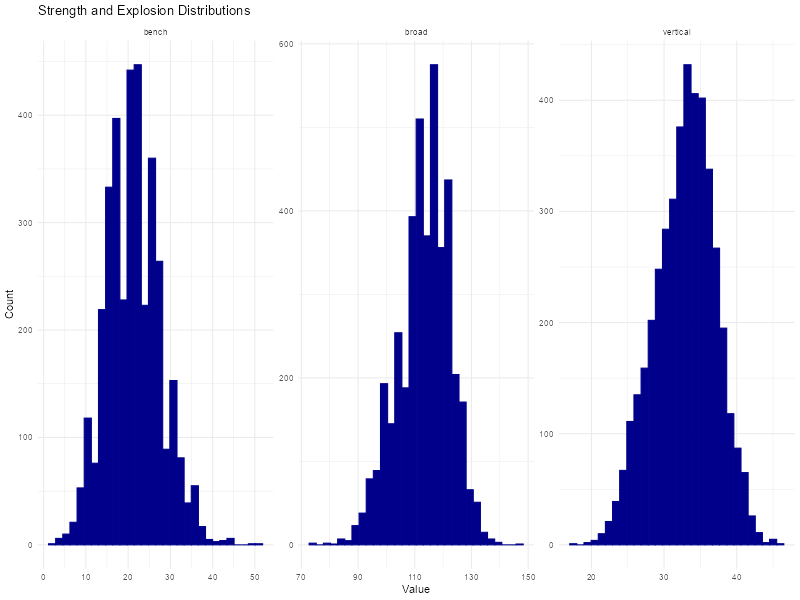

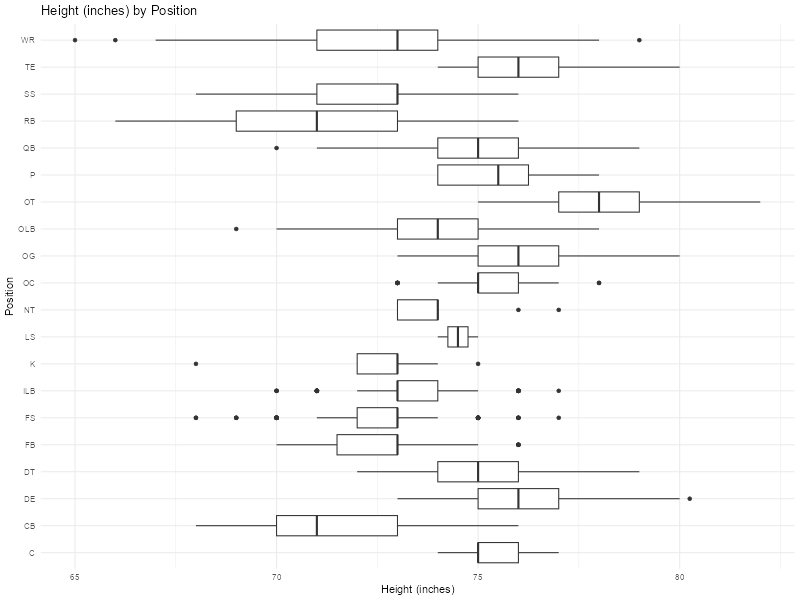

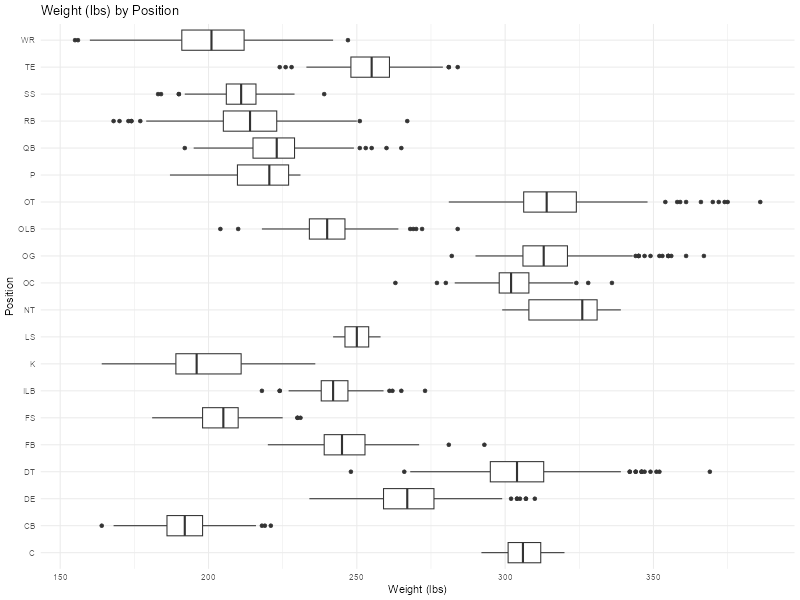

In [5]:
df <- df |> mutate(position = as.factor(position))

# ---------------------------
# 1) Correlation heatmap
# ---------------------------

# Pick numeric combine metrics you care about (adjust if your file differs)
metric_cols <- c(
  "heightinchestotal", "weight", "arms", "hands",
  "fortyyd", "twentyyd", "tenyd", "twentyss", "threecone",
  "vertical", "broad", "bench",
  "wonderlic", "nflgrade", "picktotal"
)

num_df <- df |> 
  select(any_of(metric_cols)) |> 
  select(where(is.numeric))

cor_mat <- cor(num_df, use = "pairwise.complete.obs")

corrplot(
  cor_mat,
  method = "color",
  type = "upper",
  tl.col = "black",
  tl.cex = 0.8,
  na.label = " ",
  addCoef.col = "black",     # add correlation numbers
  number.cex = 0.7,          # size of numbers
  number.digits = 2,         # round to 2 decimals
  diag = FALSE               # remove diagonal 1.00 values
)

# ---------------------------
# 2) Distribution histograms
#    Speed + Strength
# ---------------------------

speed_cols <- c("fortyyd", "twentyyd", "tenyd", "twentyss", "threecone")
strength_cols <- c("bench", "vertical", "broad")

# Speed distributions (faceted histograms)
df |> 
  select(any_of(speed_cols)) |> 
  pivot_longer(cols = everything(), names_to = "metric", values_to = "value") |> 
  filter(!is.na(value)) |> 
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, color = 'firebrick', fill = 'firebrick') +
  facet_wrap(~ metric, scales = "free") +
  labs(
    title = "Speed Drill Distributions",
    x = "Value",
    y = "Count"
  ) +
  theme_minimal()

# Strength/explosiveness distributions (faceted histograms)
df |> 
  select(any_of(strength_cols)) |> 
  pivot_longer(cols = everything(), names_to = "metric", values_to = "value") |> 
  filter(!is.na(value)) |> 
  ggplot(aes(x = value)) +
  geom_histogram(bins = 30, color = 'DarkBlue', fill = 'DarkBlue') +
  facet_wrap(~ metric, scales = "free") +
  labs(
    title = "Strength and Explosion Distributions",
    x = "Value",
    y = "Count"
  ) +
  theme_minimal()

# ---------------------------
# 3) Boxplots: height and weight by position
# ---------------------------

# Height by position
df |> 
  filter(!is.na(position), !is.na(heightinchestotal)) |> 
  ggplot(aes(x = position, y = heightinchestotal)) +
  geom_boxplot() +
  coord_flip() +
  labs(
    title = "Height (inches) by Position",
    x = "Position",
    y = "Height (inches)"
  ) +
  theme_minimal()

# Weight by position
df |> 
  filter(!is.na(position), !is.na(weight)) |> 
  ggplot(aes(x = position, y = weight)) +
  geom_boxplot() +
  coord_flip() +
  labs(
    title = "Weight (lbs) by Position",
    x = "Position",
    y = "Weight (lbs)"
  ) +
  theme_minimal()

## Combine Metrics Correlation Heatmap — Interpretation

This heatmap highlights the relationships between physical traits, athletic testing, and draft evaluation metrics.

### Size relationships

* Height and weight are strongly correlated (**0.71**), and both show moderate correlations with arm length and hand size.
* This confirms expected body-size clustering: larger athletes tend to be taller, heavier, and have longer arms and bigger hands.

### Speed metrics move together

All sprint splits show very strong positive correlations:

* **40-yard dash vs 20-yard split:** 0.91
* **10-yard vs 20-yard split:** 0.78
* **Shuttle vs 3-cone:** 0.85

These drills largely measure the same underlying trait, overall speed and agility. Faster athletes are consistently fast across multiple tests.

### Explosion vs speed tradeoff

* Vertical and broad jump show strong positive correlation (**0.81**), meaning they measure the same explosiveness trait.
* Both have strong negative correlations with sprint times (around **−0.7 to −0.8**).
* Because lower sprint times are better, this means more explosive athletes are generally faster.

### Size vs speed tradeoff

Weight has strong negative relationships with speed drills:

* **Weight vs 40-yard dash:** −0.87
* **Weight vs vertical:** −0.64
* **Weight vs broad:** −0.71

This reflects the classic football tradeoff: bigger athletes are generally slower and less explosive.

### Bench press stands apart

Bench press shows weak correlations with most speed and agility drills. Upper-body strength appears to be a relatively independent athletic trait.

### Draft evaluation signal

* **NFL grade vs pick total:** −0.61
* Lower pick numbers mean earlier selection, so higher graded prospects are drafted earlier.
* Combine testing shows relatively weak direct correlations with draft grade, suggesting teams evaluate prospects using many additional factors beyond raw athletic testing.

---

## Speed Drill Distributions — Interpretation

These histograms show the distribution of NFL Combine speed and agility drill results across athletes.

### Overall pattern

* Most drill times form roughly normal (bell-shaped) distributions.
* Each drill shows a right-skewed tail, meaning there are more slower outliers than faster outliers.
* Elite speed is rare, while slower times are more common across positions.

### 40-yard dash (fortyyd)

* Widest spread of results.
* Most athletes cluster around **4.5–4.7 seconds**.
* Long tail extends past **5.5 seconds** due to positional differences.

### 10- and 20-yard splits (tenyd, twentyyd)

* Tight clustering and narrow variance.
* Short-area burst is more consistent across athletes.
* These metrics are critical for acceleration and explosiveness off the line.

### 20-yard shuttle (twentyss)

* Moderately tight distribution centered near **4.2–4.5 seconds**.
* Right tail likely reflects slower, larger positions.
* Captures lateral quickness and change-of-direction ability.

### 3-cone drill (threecone)

* Slightly wider distribution centered around **7.0–7.3 seconds**.
* Noticeable right tail.
* Tests agility, balance, and body control.

---

## Strength and Explosion Distributions — Interpretation

These histograms display the distribution of upper-body strength and lower-body explosiveness across NFL Combine participants.

### Bench press

* Widest spread of results.
* Range: near **0 to 40+ reps**.
* Most athletes cluster around **18–25 reps**.
* Right tail likely represents linemen.

### Broad jump

* Near-normal distribution centered around **105–115 inches**.
* Tight clustering suggests consistent lower-body explosiveness across athletes.

### Vertical jump

* Bell-shaped distribution centered around **32–36 inches**.
* Most athletes fall within a narrow band of lower-body power.

---

## Height by Position — Interpretation

This boxplot compares height distributions across NFL positions and shows positional body archetypes.

### Tallest positions

* Offensive tackles and guards: **76–78 inches (6’4–6’6)** median.
* Several players exceed **80 inches**.
* Defensive ends and tackles also trend tall.

### Tall skill group

* Quarterbacks and tight ends cluster around **75–77 inches**.
* Height supports throwing lanes and catch radius.

### Shorter positions

* Running backs, cornerbacks, safeties: **70–72 inches** median.
* Emphasis on agility and change-of-direction.

### Specialists

* Kickers and long snappers are shortest.
* Extreme size is not critical.

### Variation within positions

* Wide receivers and defensive backs show wider spreads.
* Linemen show tighter clustering due to strict physical requirements.

---

## Weight by Position — Interpretation

This boxplot shows body mass differences across NFL positions.

### Linemen dominate the upper range

* Offensive tackles and guards: **305–330 lbs**.
* Some outliers approach **350+ lbs**.
* Defensive tackles show similar mass.

### Interior vs edge defenders

* Defensive ends: **260–285 lbs**.
* Reflects balance of size and speed for edge rushing.

### Middle tier

* Quarterbacks and tight ends: **230–255 lbs**.
* Balance size, durability, and mobility.

### Speed positions

* Wide receivers, cornerbacks, safeties, running backs: **185–215 lbs**.
* Prioritize speed and acceleration.

### Specialists

* Kickers and long snappers sit on the lower end of the distribution.


In [6]:
forty_by_year <- df |>
  group_by(year) |>
  summarise(avg_forty = mean(fortyyd, na.rm = TRUE)) # grouping by year calculating the average 40 time

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was generated. 


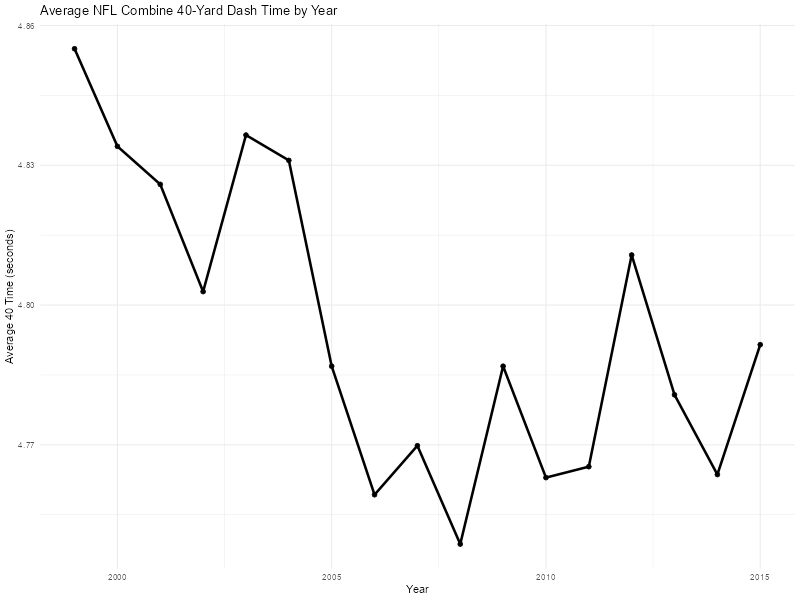

In [7]:
ggplot(forty_by_year, aes(x = year, y = avg_forty)) +
  geom_line(size = 1.2) +
  geom_point(size = 2) +
  labs(
    title = "Average NFL Combine 40-Yard Dash Time by Year",
    x = "Year",
    y = "Average 40 Time (seconds)"
  ) +
  theme_minimal()

## Average NFL Combine 40-Yard Dash Time by Year — Interpretation

The line chart shows a clear long-term improvement in average 40-yard dash performance across NFL Combine participants.

### Long-term trend

The most noticeable pattern is the steady decline from the late 1990s through the mid-2000s. Average times drop from roughly **4.85 seconds to about 4.76 seconds**, indicating athletes entering the league became meaningfully faster during this period. This likely reflects advances in strength and conditioning, sports science, and year-round training.

### Plateau in recent years

After the mid-2000s, the trend stabilizes. From about **2007 onward**, the line fluctuates within a tight range around **4.76–4.80 seconds**. This suggests the Combine may be approaching a performance ceiling, where improvements become incremental rather than dramatic.

### Year-to-year variation

Small spikes and dips appear throughout the timeline. These fluctuations likely reflect differences in the positional makeup of each draft class. Years with more linemen tend to increase the average time, while classes with more skill-position athletes tend to decrease it.

### Overall takeaway

The chart supports the conclusion that modern NFL prospects are faster than earlier cohorts, with the most significant improvements occurring before performance began to level off.


# Future Plans

How do combine performance metrics differ by position?
Combine results show strong positional specialization. Linemen consistently dominate size and strength metrics, including weight and bench press, but trail in speed and agility drills. Skill positions such as wide receivers, defensive backs, and running backs excel in the 40-yard dash, shuttle, and 3-cone, reflecting the importance of acceleration and change-of-direction. Quarterbacks and tight ends typically fall between these groups, balancing size with moderate athleticism. Overall, positional archetypes appear clearly defined, with each position emphasizing a distinct athletic profile.

Which combine metrics are most associated with being drafted?
Initial correlations suggest only moderate relationships between combine performance and draft outcomes. Explosiveness and speed metrics show some association with earlier draft selection, while bench press appears weakly related. Draft grade is more strongly connected to pick order than individual drills, indicating teams likely combine film evaluation, college performance, and positional value with athletic testing rather than relying heavily on raw combine metrics alone.

How have combine athletes changed over time?
Preliminary trends suggest athletes have become faster and more explosive while maintaining or increasing size. This implies a shift toward larger athletes who still meet elite speed thresholds. The evolution likely reflects advances in sports science, strength training, and position-specific development programs.

What physical traits do early round draft picks share?
Early draft selections tend to show strong explosiveness and speed relative to their positional peers. Rather than simply being the biggest or strongest, these athletes appear to combine size with above-average athleticism. This supports the idea that teams prioritize rare athletic profiles that exceed positional norms.

Future refinement of the analysis
As the study progresses into data wrangling, regression, and predictive modeling, the analysis will shift from descriptive exploration to more rigorous statistical evaluation. Data cleaning and feature engineering will allow more precise comparisons across positions and years. Regression models can quantify the relative importance of each metric in predicting draft outcomes, while classification approaches can identify traits shared by early-round selections. These techniques will help transform exploratory insights into testable hypotheses and predictive frameworks.